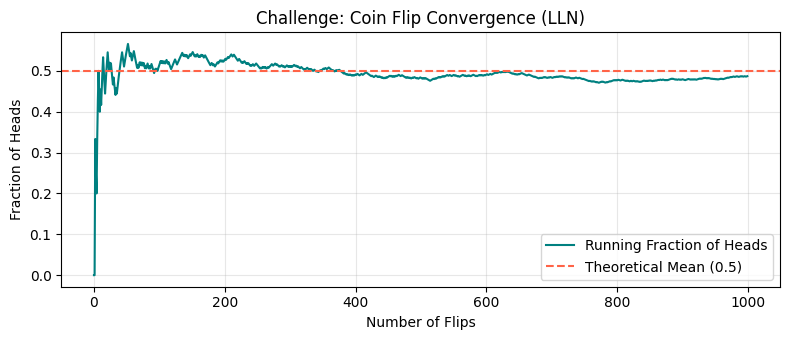

In [11]:
# Probability Basics Challenge
import numpy as np
import matplotlib.pyplot as plt

n_flips = 1000
flips = np.random.randint(0, 2, size=n_flips)


running_heads_fraction = np.cumsum(flips) / np.arange(1, n_flips + 1)

plt.figure(figsize=(8, 3.5))
plt.plot(running_heads_fraction, color='teal', label='Running Fraction of Heads')
plt.axhline(0.5, color='tomato', linestyle='--', label='Theoretical Mean (0.5)')
plt.xlabel('Number of Flips')
plt.ylabel('Fraction of Heads')
plt.title('Challenge: Coin Flip Convergence (LLN)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
# Markov Chains Challenge
T_4state = np.array([
    [0.6, 0.2, 0.1, 0.1],
    [0.2, 0.4, 0.2, 0.2],
    [0.2, 0.2, 0.4, 0.2],
    [0.1, 0.2, 0.3, 0.4]
])

assert np.allclose(T_4state.sum(axis=1), 1.0), "Rows must sum to 1!"

eigenvalues, eigenvectors = np.linalg.eig(T_4state.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi = np.real(eigenvectors[:, idx])
pi /= pi.sum()

print("Stationary Distribution (π):", np.round(pi, 4))
assert np.allclose(pi @ T_4state, pi), "Proof Failed: π @ T does not equal π!"
print("Assertion Passed! Mathematical proof verified successfully.")


Stationary Distribution (π): [0.2979 0.25   0.2394 0.2128]
Assertion Passed! Mathematical proof verified successfully.


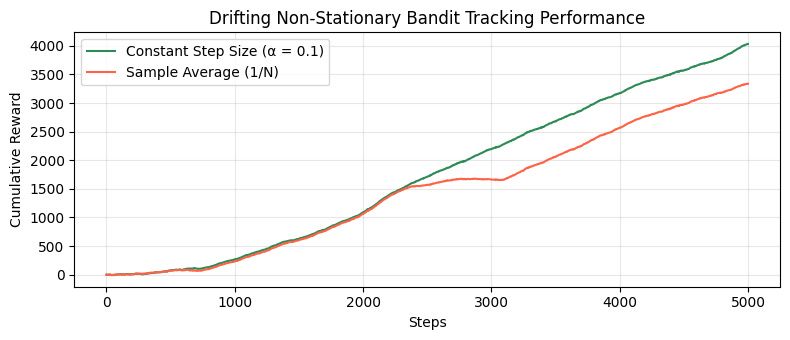

In [13]:
#Multi-Armed Bandit Challenge
import numpy as np
import matplotlib.pyplot as plt
def epsilon_greedy(eps):
    return lambda Q, N, t: np.random.randint(len(Q)) if np.random.rand() < eps else np.argmax(Q)
class NonStationaryBandit:
    def __init__(self, n_arms=10, drift_rate=0.02):
        self.n_arms = n_arms
        self.drift_rate = drift_rate
        self.true_means = np.zeros(n_arms)
        self.optimal_arm = np.argmax(self.true_means)

    def pull(self, arm):
        reward = np.random.normal(self.true_means[arm], 1.0)
        self.true_means += np.random.normal(0, self.drift_rate, self.n_arms)
        self.optimal_arm = np.argmax(self.true_means)
        return reward
def run_nonstationary_agent(bandit, policy, alpha=None, n_steps=5000):
    n_arms = bandit.n_arms
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = []

    for t in range(n_steps):
        arm = policy(Q, N, t)
        reward = bandit.pull(arm)
        N[arm] += 1
        if alpha is None:
            step_size = 1.0 / N[arm]
        else:
            step_size = alpha

        Q[arm] += step_size * (reward - Q[arm])
        rewards.append(reward)

    return np.array(rewards)
np.random.seed(42)
drift_bandit_1 = NonStationaryBandit(n_arms=10, drift_rate=0.02)
rewards_sample_avg = run_nonstationary_agent(drift_bandit_1, epsilon_greedy(0.1), alpha=None)
np.random.seed(42)
drift_bandit_2 = NonStationaryBandit(n_arms=10, drift_rate=0.02)
rewards_constant_alpha = run_nonstationary_agent(drift_bandit_2, epsilon_greedy(0.1), alpha=0.1)
plt.figure(figsize=(8, 3.5))
plt.plot(np.cumsum(rewards_constant_alpha), color='seagreen', label='Constant Step Size (α = 0.1)')
plt.plot(np.cumsum(rewards_sample_avg), color='tomato', label='Sample Average (1/N)')
plt.xlabel('Steps')
plt.ylabel('Cumulative Reward')
plt.title('Drifting Non-Stationary Bandit Tracking Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [14]:
#Random Walk Challenge
import numpy as np

def simulate_sutton_walk(start_state):
    state = start_state
    while True:
        state += np.random.choice([-1, 1])
        if state == 0:
            return 0.0
        if state == 6:
            return 1.0
n_episodes = 50_000
states = ['A', 'B', 'C', 'D', 'E']
empirical_values = []

for s_idx in range(1, 6):
    returns = [simulate_sutton_walk(s_idx) for _ in range(n_episodes)]
    empirical_values.append(np.mean(returns))
theoretical_values = [1/6, 2/6, 3/6, 4/6, 5/6]

print(f"{'State':<7} | {'Empirical Value':<15} | {'Theoretical Value':<17} | {'Difference'}")
print("-" * 60)
for name, emp, theo in zip(states, empirical_values, theoretical_values):
    print(f"State {name} | {emp:.4f}          | {theo:.4f}            | {abs(emp - theo):.4f}")
assert np.allclose(empirical_values, theoretical_values, atol=0.01)
print("\nAssertion passed: Empirical values match theoretical values within 0.01 tolerance!")


State   | Empirical Value | Theoretical Value | Difference
------------------------------------------------------------
State A | 0.1675          | 0.1667            | 0.0009
State B | 0.3306          | 0.3333            | 0.0028
State C | 0.4991          | 0.5000            | 0.0009
State D | 0.6664          | 0.6667            | 0.0002
State E | 0.8349          | 0.8333            | 0.0016

Assertion passed: Empirical values match theoretical values within 0.01 tolerance!


 The proof calculates the state values (A=1/6, B=2/6, C=3/6, D=4/6, E=5/6) using the Bellman equation, while the Python code (using 50,000 episodes) confirms these results with a comparison table and assertion, verifying the simulation works correctly [1.1].
